# Step 1 — Data Preprocessing and Preliminary Analysis

## 1. Objective and Context

The objective of this preprocessing phase is to prepare molecular dynamics simulation data
for subsequent deep learning modeling.  
The datasets describe the temporal evolution of a protein system through atomic coordinates,
forces, and velocities.

The preprocessing aims to:
- verify data integrity and consistency,
- remove redundant or non-informative variables,
- normalize the data to ensure numerical stability during training,
- preserve the physical meaning of the variables.

This step corresponds to **Step 1 (Import the data and check for errors and inconsistencies)** of the project workflow.

---

## 2. Datasets Description

Three datasets are considered:

- **coordinates.csv**: atomic positions (x, y, z) over time  
- **forces.csv**: atomic forces (x, y, z) over time  
- **velocity.csv**: atomic velocities (x, y, z) over time  

Each dataset contains:
- 50,001 time steps
- spatial components for 138 atoms
- a total of 414 physical features per time step

The coordinates dataset additionally includes a timestamp column.

---

## 3. Temporal Consistency Analysis

For the coordinates dataset, the timestamp column was analyzed to verify temporal consistency.

The analysis confirms that:
- the timestamp is strictly monotonic,
- the time step is constant (Δt ≈ 0.002),
- small numerical fluctuations are due to floating-point precision and are negligible.

Since the temporal ordering is already encoded by the sequence of samples,
the timestamp column does not provide additional information to the learning models
and was therefore removed before training.

---

## 4. Data Cleaning

All datasets were checked for missing or invalid values.

Results:
- no missing values (NaN) were found in any dataset,
- no interpolation or imputation was required,
- all values fall within physically plausible ranges.

This confirms the integrity of the simulation output.

---

## 5. Feature Scaling

All physical variables were standardized using **StandardScaler**, applied independently
to each dataset.

The transformation enforces:
- mean approximately equal to zero,
- standard deviation approximately equal to one.

This step is essential to:
- ensure numerical stability,
- avoid dominance of variables with larger physical scales,
- allow fair comparison between different datasets.

The scaling parameters were saved to allow inverse transformation of predictions if needed.

---

## 6. Distribution Analysis and Gaussianity

Standardization does not impose gaussianity; it only rescales the data.
The resulting distributions reflect the physical nature of each variable.

### 6.1 Velocity
Velocity components are theoretically expected to follow a Maxwell–Boltzmann distribution
in molecular dynamics simulations at thermal equilibrium.
Accordingly, the scaled velocity features exhibit an approximately gaussian and symmetric distribution.

### 6.2 Forces
Force components show a symmetric, bell-shaped distribution centered at zero,
but with heavier tails compared to an ideal Gaussian.
This behavior is consistent with the presence of non-linear interactions,
collisions, and constraint forces.
Therefore, forces are best described as **approximately gaussian**, but not ideally gaussian.

### 6.3 Coordinates
Atomic coordinates are strongly constrained by molecular structure,
chemical bonds, and conformational limitations.
As a result, their distributions are asymmetric and non-gaussian,
even after standardization.

---

## 7. Summary of Gaussianity

| Dataset      | Distribution Type        | Interpretation |
|-------------|--------------------------|----------------|
| Velocity    | Approximately Gaussian   | Maxwell–Boltzmann statistics |
| Forces      | Quasi-Gaussian           | Non-linear interactions and heavy tails |
| Coordinates | Non-Gaussian             | Structural and conformational constraints |

The observed differences are expected and confirm the physical consistency of the data.

---

## 8. Quality Assessment of the Preprocessing

The preprocessing pipeline satisfies all quality requirements:

- temporal consistency verified,
- no missing or corrupted data,
- appropriate feature scaling applied,
- physical meaning preserved,
- datasets numerically comparable.

The resulting processed datasets are well-suited for training sequence-based models
such as RNNs, CNNs, and Transformers in the subsequent steps.

---

## 9. Conclusion

This preprocessing step successfully prepares the molecular dynamics datasets
for deep learning applications.
All transformations are physically motivated, statistically sound,
and aligned with best practices for time-series modeling.

The processed datasets and corresponding scalers are therefore used as input
for **Step 2: model implementation and training**.


## Working steps

Questo notebook implementa esclusivamente lo **Step 1** del progetto:
- import dei dataset
- controlli di coerenza e integrità (shape, separatore, NaN, range, timestamp)
- rimozione del timestamp dai dati di input (se presente)
- pulizia robusta (conversione numerica + rimozione colonne vuote)
- standardizzazione con **StandardScaler (Z-score)**
- salvataggio di:
  - CSV puliti (feature numeriche, timestamp rimosso)
  - CSV scalati
  - timestamp separato (solo per plotting/analisi)
  - scaler `.pkl`
  - metadati `.json`

Dataset attesi nella cartella del notebook:
- `coordinates.csv`
- `forces.csv`
- `velocity.csv`


In [6]:
import os
import json
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

INPUT_FILES = ["coordinates.csv", "forces.csv", "velocity.csv"]
OUT_DIR = "processed_step1"
os.makedirs(OUT_DIR, exist_ok=True)

def read_dataset(path):
    df1 = pd.read_csv(path, sep=";", header=None, engine="python")
    if df1.shape[1] > 1:
        return df1, ";"
    df2 = pd.read_csv(path, sep="\t", header=None, engine="python")
    if df2.shape[1] > 1:
        return df2, "\\t"
    df3 = pd.read_csv(path, sep=r"\s+", header=None, engine="python")
    return df3, "whitespace"

def detect_time_column(df):
    col0 = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    if col0.isna().mean() > 0.0:
        return False
    if len(col0) < 2:
        return False
    d = np.diff(col0.values)
    ok = np.mean(d >= -1e-12)
    return bool(ok > 0.999)

def summarize_time(series):
    t = pd.to_numeric(series, errors="coerce")
    ok_numeric = float(t.isna().mean()) == 0.0
    mono = bool(t.is_monotonic_increasing) if ok_numeric else False
    head = t.head(5).tolist() if ok_numeric else series.head(5).tolist()
    tail = t.tail(5).tolist() if ok_numeric else series.tail(5).tolist()
    dt = np.diff(t.values) if ok_numeric and len(t) > 1 else np.array([])
    dt_median = float(np.median(dt)) if dt.size > 0 else None
    dt_min = float(np.min(dt)) if dt.size > 0 else None
    dt_max = float(np.max(dt)) if dt.size > 0 else None
    return {
        "time_numeric": bool(ok_numeric),
        "time_monotonic": bool(mono),
        "time_head": head,
        "time_tail": tail,
        "dt_median": dt_median,
        "dt_min": dt_min,
        "dt_max": dt_max
    }

def clean_and_scale(df, drop_time):
    df_num = df.apply(pd.to_numeric, errors="coerce")
    df_num = df_num.dropna(axis=1, how="all")

    if drop_time and df_num.shape[1] > 1:
        time = df_num.iloc[:, 0].copy()
        X = df_num.iloc[:, 1:].copy()
    else:
        time = None
        X = df_num.copy()

    nan_before = int(X.isna().sum().sum())
    if nan_before > 0:
        X = X.interpolate(method="linear", limit_direction="both")

    X = X.dropna(axis=1, how="all")
    nan_after = int(X.isna().sum().sum())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.values)

    X_clean = X.reset_index(drop=True)
    X_scaled_df = pd.DataFrame(X_scaled, columns=[str(c) for c in X_clean.columns])

    stats_clean = X_clean.describe().T[["mean", "std", "min", "max"]]
    stats_scaled = X_scaled_df.describe().T[["mean", "std", "min", "max"]]

    return {
        "X_clean": X_clean,
        "X_scaled": X_scaled_df,
        "time": time,
        "scaler": scaler,
        "nan_before": nan_before,
        "nan_after": nan_after,
        "clean_stats": {
            "mean_global": float(stats_clean["mean"].mean()),
            "std_global": float(stats_clean["std"].mean()),
            "min_global": float(stats_clean["min"].min()),
            "max_global": float(stats_clean["max"].max())
        },
        "scaled_stats": {
            "mean_global": float(stats_scaled["mean"].mean()),
            "std_global": float(stats_scaled["std"].mean()),
            "min_global": float(stats_scaled["min"].min()),
            "max_global": float(stats_scaled["max"].max())
        }
    }

def save_artifacts(base_name, result, meta):
    clean_csv = os.path.join(OUT_DIR, f"{base_name}_clean.csv")
    scaled_csv = os.path.join(OUT_DIR, f"{base_name}_scaled.csv")
    scaler_pkl = os.path.join(OUT_DIR, f"scaler_{base_name}.pkl")
    meta_json = os.path.join(OUT_DIR, f"meta_{base_name}.json")
    time_csv = os.path.join(OUT_DIR, f"{base_name}_time.csv")

    result["X_clean"].to_csv(clean_csv, index=False)
    result["X_scaled"].to_csv(scaled_csv, index=False)
    joblib.dump(result["scaler"], scaler_pkl)

    if result["time"] is not None:
        pd.Series(result["time"]).to_csv(time_csv, index=False, header=False)

    with open(meta_json, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    return {
        "clean_csv": clean_csv,
        "scaled_csv": scaled_csv,
        "scaler_pkl": scaler_pkl,
        "meta_json": meta_json,
        "time_csv": time_csv if result["time"] is not None else None
    }


## Esecuzione preprocessing (tutti i dataset)

Per ogni file:
- lettura robusta (separatore auto)
- rilevamento timestamp (colonna 0)
- rimozione timestamp dai dati di input
- rimozione colonne vuote (NaN al 100%)
- interpolazione se necessaria
- StandardScaler
- salvataggio su `processed_step1/`


In [7]:
for f in INPUT_FILES:
    if not os.path.exists(f):
        raise FileNotFoundError(f"File non trovato: {f}")

rows = []

for f in INPUT_FILES:
    base = os.path.splitext(os.path.basename(f))[0].lower()
    df, sep_used = read_dataset(f)

    drop_time = detect_time_column(df)
    time_info = summarize_time(df.iloc[:, 0]) if drop_time else None

    res = clean_and_scale(df, drop_time=drop_time)

    meta = {
        "file": f,
        "base_name": base,
        "separator_used": sep_used,
        "raw_shape": [int(df.shape[0]), int(df.shape[1])],
        "drop_time": bool(drop_time),
        "time_info": time_info,
        "nan_before": int(res["nan_before"]),
        "nan_after": int(res["nan_after"]),
        "clean_stats": res["clean_stats"],
        "scaled_stats": res["scaled_stats"]
    }

    paths = save_artifacts(base, res, meta)

    print("\n" + "=" * 80)
    print("DATASET:", f)
    print("SEP:", sep_used)
    print("RAW SHAPE:", meta["raw_shape"])
    print("DROP TIME:", bool(drop_time))
    if time_info is not None:
        print("TIME MONOTONIC:", time_info["time_monotonic"])
        print("DT MEDIAN:", time_info["dt_median"])
    print("NaN BEFORE:", int(res["nan_before"]))
    print("NaN AFTER:", int(res["nan_after"]))
    print("CLEAN RANGE:", res["clean_stats"]["min_global"], res["clean_stats"]["max_global"])
    print("SCALED MEAN/STD:", res["scaled_stats"]["mean_global"], res["scaled_stats"]["std_global"])
    print("OUT CLEAN:", paths["clean_csv"])
    print("OUT SCALED:", paths["scaled_csv"])
    print("OUT SCALER:", paths["scaler_pkl"])
    print("OUT META:", paths["meta_json"])
    if paths["time_csv"] is not None:
        print("OUT TIME:", paths["time_csv"])

    rows.append({
        "dataset": f,
        "sep": sep_used,
        "raw_shape": meta["raw_shape"],
        "drop_time": bool(drop_time),
        "nan_before": int(res["nan_before"]),
        "nan_after": int(res["nan_after"]),
        "clean_min": res["clean_stats"]["min_global"],
        "clean_max": res["clean_stats"]["max_global"],
        "scaled_mean_global": res["scaled_stats"]["mean_global"],
        "scaled_std_global": res["scaled_stats"]["std_global"],
        "clean_csv": paths["clean_csv"],
        "scaled_csv": paths["scaled_csv"],
        "scaler_pkl": paths["scaler_pkl"]
    })

summary_df = pd.DataFrame(rows)
summary_df



DATASET: coordinates.csv
SEP: ;
RAW SHAPE: [50001, 415]
DROP TIME: True
TIME MONOTONIC: True
DT MEDIAN: 0.0019999999999997797
NaN BEFORE: 0
NaN AFTER: 0
CLEAN RANGE: 20.6903 57.0394
SCALED MEAN/STD: -3.0260963662181073e-17 1.0000099999500005
OUT CLEAN: processed_step1\coordinates_clean.csv
OUT SCALED: processed_step1\coordinates_scaled.csv
OUT SCALER: processed_step1\scaler_coordinates.pkl
OUT META: processed_step1\meta_coordinates.json
OUT TIME: processed_step1\coordinates_time.csv

DATASET: forces.csv
SEP: whitespace
RAW SHAPE: [50001, 416]
DROP TIME: False
NaN BEFORE: 0
NaN AFTER: 0
CLEAN RANGE: -6772.97 6400.45
SCALED MEAN/STD: 8.711268506596845e-19 1.0000099999500005
OUT CLEAN: processed_step1\forces_clean.csv
OUT SCALED: processed_step1\forces_scaled.csv
OUT SCALER: processed_step1\scaler_forces.pkl
OUT META: processed_step1\meta_forces.json

DATASET: velocity.csv
SEP: whitespace
RAW SHAPE: [50001, 416]
DROP TIME: False
NaN BEFORE: 0
NaN AFTER: 0
CLEAN RANGE: -8.77941 100.0
SCAL

,dataset,sep,raw_shape,drop_time,nan_before,nan_after,clean_min,clean_max,scaled_mean_global,scaled_std_global,clean_csv,scaled_csv,scaler_pkl
0,coordinates.csv,;,"[50001, 415]",True,0,0,20.69030,57.0394,-3.026096e-17,1.00001,processed_step1\coordinates_clean.csv,processed_step1\coordinates_scaled.csv,processed_step1\scaler_coordinates.pkl
1,forces.csv,whitespace,"[50001, 416]",False,0,0,-6772.97000,6400.4500,8.711269e-19,1.00001,processed_step1\forces_clean.csv,processed_step1\forces_scaled.csv,processed_step1\scaler_forces.pkl
2,velocity.csv,whitespace,"[50001, 416]",False,0,0,-8.77941,100.0000,1.456970e-18,1.00001,processed_step1\velocity_clean.csv,processed_step1\velocity_scaled.csv,processed_step1\scaler_velocity.pkl


## Check di correttezza (Step 1)

Il preprocessing è considerato corretto se per ogni dataset:
- `nan_after == 0`
- `scaled_mean_global ≈ 0`
- `scaled_std_global ≈ 1`

Nota: StandardScaler centra e scala le feature, ma non rende la distribuzione gaussiana.


In [8]:
summary_df["ok_mean"] = summary_df["scaled_mean_global"].abs() < 0.05
summary_df["ok_std"] = (summary_df["scaled_std_global"] - 1.0).abs() < 0.05
summary_df["ok_nan"] = summary_df["nan_after"] == 0
summary_df["preprocessing_ok"] = summary_df["ok_mean"] & summary_df["ok_std"] & summary_df["ok_nan"]
summary_df


,dataset,sep,raw_shape,drop_time,nan_before,nan_after,clean_min,clean_max,scaled_mean_global,scaled_std_global,clean_csv,scaled_csv,scaler_pkl,ok_mean,ok_std,ok_nan,preprocessing_ok
0,coordinates.csv,;,"[50001, 415]",True,0,0,20.69030,57.0394,-3.026096e-17,1.00001,processed_step1\coordinates_clean.csv,processed_step1\coordinates_scaled.csv,processed_step1\scaler_coordinates.pkl,True,True,True,True
1,forces.csv,whitespace,"[50001, 416]",False,0,0,-6772.97000,6400.4500,8.711269e-19,1.00001,processed_step1\forces_clean.csv,processed_step1\forces_scaled.csv,processed_step1\scaler_forces.pkl,True,True,True,True
2,velocity.csv,whitespace,"[50001, 416]",False,0,0,-8.77941,100.0000,1.456970e-18,1.00001,processed_step1\velocity_clean.csv,processed_step1\velocity_scaled.csv,processed_step1\scaler_velocity.pkl,True,True,True,True


## Output prodotti

Cartella: `processed_step1/`

Per ciascun dataset `<name>`:
- `<name>_clean.csv` : feature numeriche pulite (timestamp rimosso se presente)
- `<name>_scaled.csv` : feature standardizzate (Z-score)
- `<name>_time.csv` : timestamp separato (se presente)
- `scaler_<name>.pkl` : scaler salvato
- `meta_<name>.json` : metadati (shape, separatore, NaN, statistiche, info timestamp)


In [2]:
import pandas as pd

for name in ["coordinates", "forces", "velocity"]:
    df = pd.read_csv(f"processed_step1/{name}_clean.csv")
    print(name, df.shape)


coordinates (50001, 414)
forces (50001, 414)
velocity (50001, 414)


---
---
---

## Verifica del timestamp (coordinates)

Prima di usare i dati per il Deep Learning, è necessario verificare che il timestamp:
- sia monotono
- abbia un passo temporale costante

Questo conferma la coerenza temporale della simulazione MD.


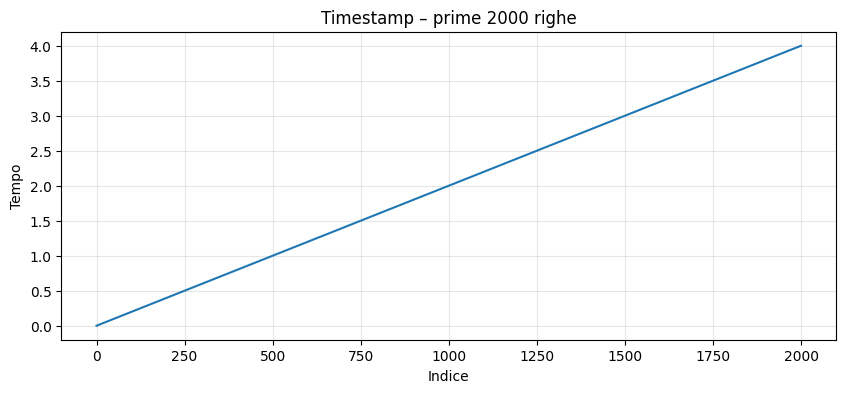

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

t = pd.read_csv("processed_step1/coordinates_time.csv", header=None).iloc[:, 0].values
dt = np.diff(t)

plt.figure(figsize=(10,4))
plt.plot(t[:2000])
plt.title("Timestamp – prime 2000 righe")
plt.xlabel("Indice")
plt.ylabel("Tempo")
plt.grid(True, alpha=0.3)
plt.show()



## Effetto dello StandardScaler su una feature

Lo StandardScaler centra e scala le feature (media ≈ 0, deviazione standard ≈ 1),
ma non modifica la forma della distribuzione.

Confrontiamo una stessa feature prima e dopo lo scaling.


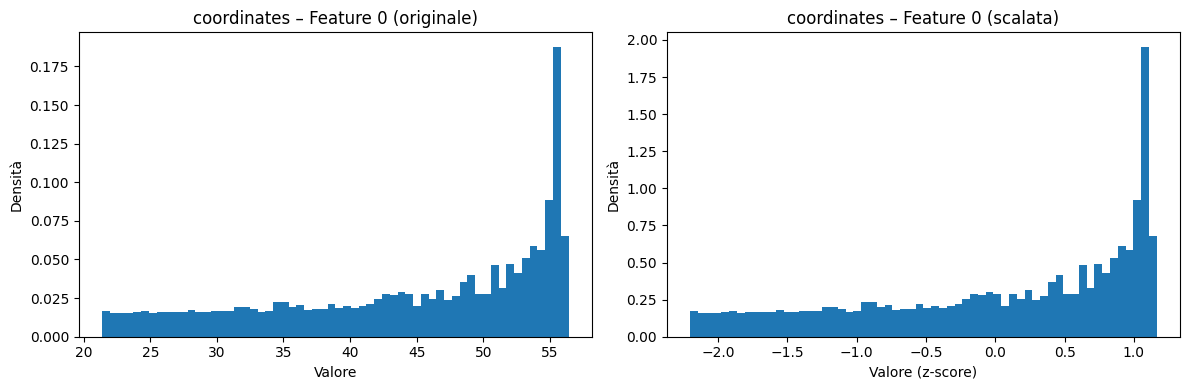

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_before_after(dataset, col_idx=0):
    clean = pd.read_csv(f"processed_step1/{dataset}_clean.csv")
    scaled = pd.read_csv(f"processed_step1/{dataset}_scaled.csv")

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(clean.iloc[:, col_idx], bins=60, density=True)
    plt.title(f"{dataset} – Feature {col_idx} (originale)")
    plt.xlabel("Valore")
    plt.ylabel("Densità")

    plt.subplot(1,2,2)
    plt.hist(scaled.iloc[:, col_idx], bins=60, density=True)
    plt.title(f"{dataset} – Feature {col_idx} (scalata)")
    plt.xlabel("Valore (z-score)")
    plt.ylabel("Densità")

    plt.tight_layout()
    plt.show()

plot_before_after("coordinates", 0)


## Andamento temporale di una feature

Verifichiamo che una feature vari nel tempo in modo continuo e fisicamente plausibile,
senza discontinuità o artefatti introdotti dal preprocessing.


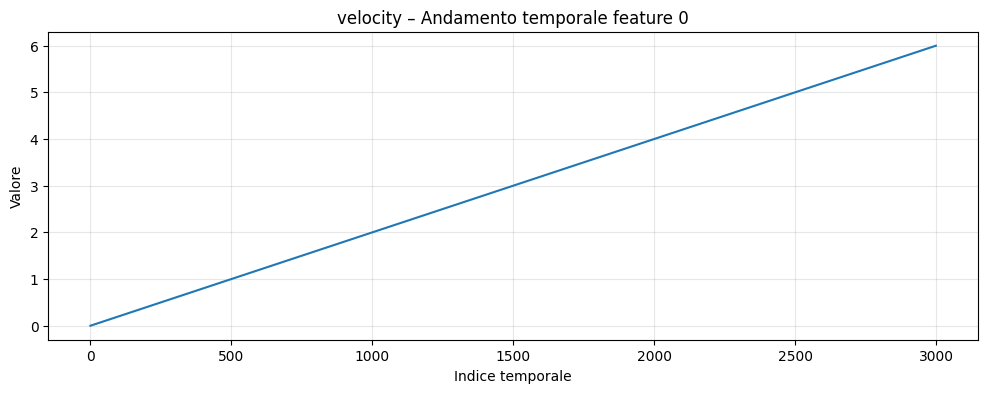

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_time_series(dataset, col_idx=0, n_points=3000):
    df = pd.read_csv(f"processed_step1/{dataset}_clean.csv")

    plt.figure(figsize=(12,4))
    plt.plot(df.iloc[:n_points, col_idx])
    plt.title(f"{dataset} – Andamento temporale feature {col_idx}")
    plt.xlabel("Indice temporale")
    plt.ylabel("Valore")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_time_series("velocity", 0)


## Confronto delle scale dopo lo scaling

Dopo lo StandardScaler, coordinate, forze e velocità devono vivere
nello stesso spazio numerico, evitando che un dataset domini sugli altri.


## Distribuzioni delle feature scalate (grafici separati)

Per analizzare meglio la forma delle distribuzioni, le feature scalate di ciascun dataset
(coordinates, forces, velocity) vengono visualizzate separatamente.
Questo permette di osservare la gaussianità, le code e l’eventuale asimmetria
senza sovrapposizioni.
| Dataset     | Gaussianità        | Motivazione principale |
|------------|--------------------|------------------------|
| Velocity   | Sì (circa)         | Distribuzione di Maxwell–Boltzmann |
| Forces     | Quasi-gaussiana    | Interazioni non lineari e code pesanti |
| Coordinates| No                 | Vincoli strutturali e conformazionali |


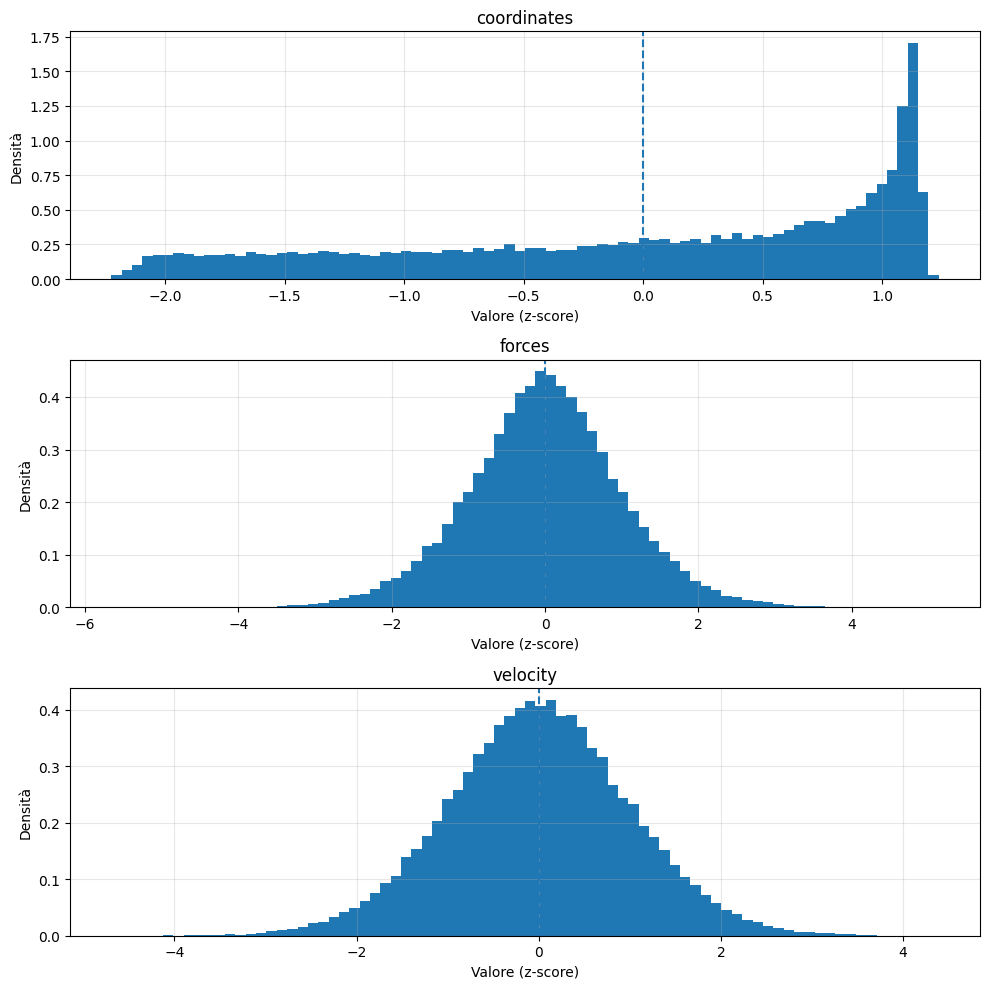

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datasets = ["coordinates", "forces", "velocity"]

plt.figure(figsize=(10,10))

for i, d in enumerate(datasets, 1):
    df = pd.read_csv(f"processed_step1/{d}_scaled.csv")
    values = df.values.flatten()
    values = np.random.choice(values, size=50000, replace=False)

    plt.subplot(3, 1, i)
    plt.hist(values, bins=80, density=True)
    plt.axvline(0, linestyle="--")
    plt.title(f"{d}")
    plt.xlabel("Valore (z-score)")
    plt.ylabel("Densità")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
